<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/Drought_Severity_CensusTract.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

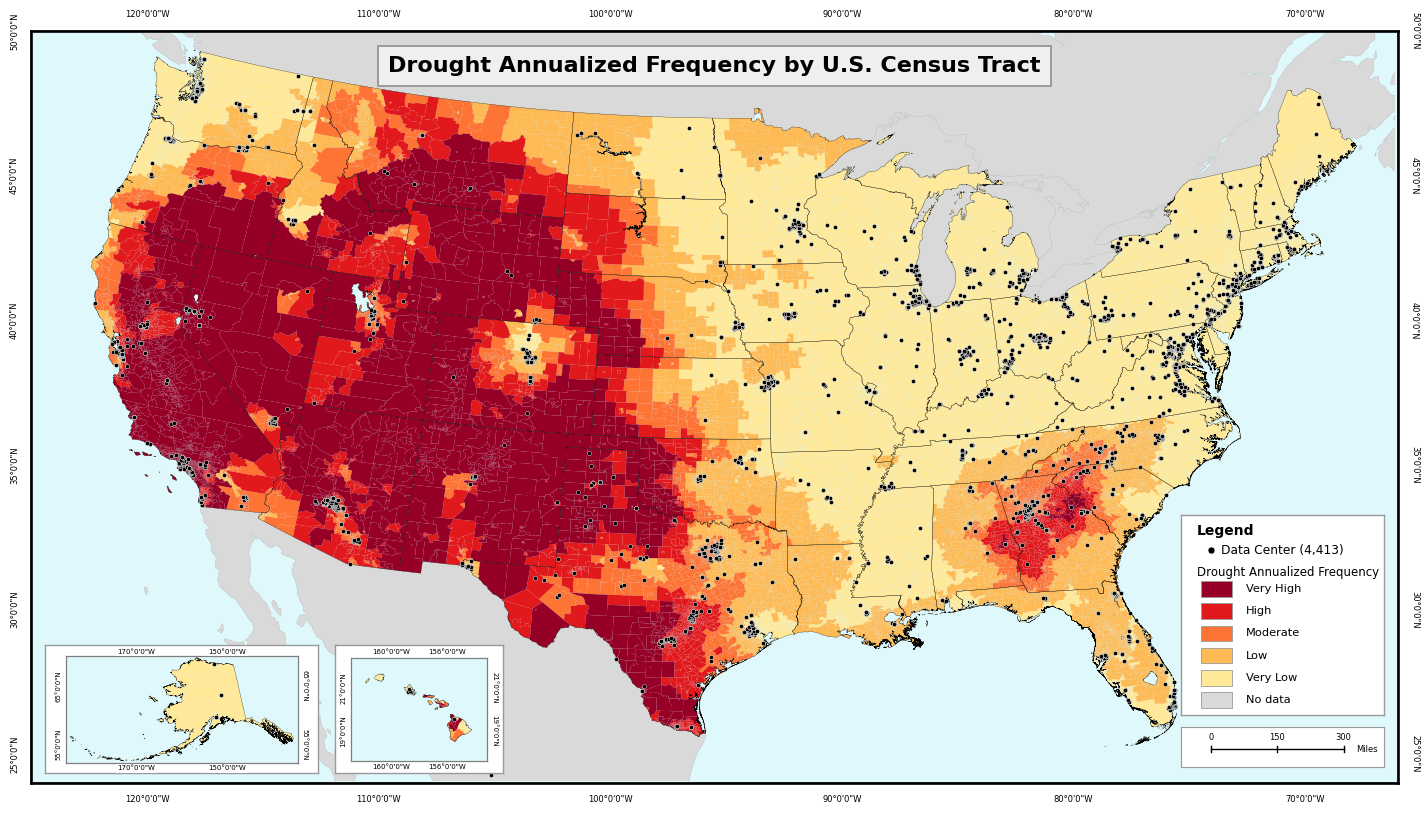

In [1]:
# Run once
# !pip install geopandas matplotlib numpy pandas shapely

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd

# Link to information download:
# https://resilience-fema.hub.arcgis.com/datasets/FEMA::national-risk-index-annualized-frequency-drought/explore?layer=1&location=42.595305%2C-93.749460%2C7

# Load drought census tract shapefile
gdf = gpd.read_file("/content/Census_Tract.shp")

# Make sure drought values are numeric
gdf["DRGT_AFREQ"] = pd.to_numeric(
    gdf["DRGT_AFREQ"],
    errors="coerce"
)

# Make sure coordinates are latitude/longitude first
gdf = gdf.to_crs(epsg=4326)

# Remove U.S. territories only
territories = [
    "Puerto Rico",
    "Virgin Islands",
    "Guam",
    "American Samoa",
    "Northern Mariana Islands"
]
gdf = gdf[~gdf["STATE"].isin(territories)].copy()

# Load data center / facility locations
facilities_file = "/content/facilities_final_complete.xlsx"

facilities = pd.read_excel(
    facilities_file,
    sheet_name="facilities_final_complete"
)

# This map works at the census-tract level, so facilities can't be
# matched by county FIPS the way the other maps do. Instead, build a
# point for each facility from its lat/lon and match it to a tract
# spatially. Facilities missing coordinates (a small share of rows)
# can't be placed reliably at that granularity and are left out.
facility_points = facilities[
    facilities["latitude"].notna() & facilities["longitude"].notna()
].copy()

facility_points = gpd.GeoDataFrame(
    facility_points,
    geometry=gpd.points_from_xy(facility_points["longitude"], facility_points["latitude"]),
    crs="EPSG:4326"
)

# Color scale
drought_values = gdf["DRGT_AFREQ"].dropna()
vmin = drought_values.quantile(0.02)
vmax = drought_values.quantile(0.98)

# Create range bins for the map
bins = np.linspace(vmin, vmax, 6)

gdf["drought_bin"] = pd.cut(
    gdf["DRGT_AFREQ"],
    bins=bins,
    labels=False,
    include_lowest=True
)

# Put out-of-range values into first/last bins
gdf.loc[gdf["DRGT_AFREQ"] < vmin, "drought_bin"] = 0
gdf.loc[gdf["DRGT_AFREQ"] > vmax, "drought_bin"] = 4

# Total number of data centers shown on the map, for the legend
total_facility_count = len(facilities)  # standardized to raw facility count for consistency across all maps/charts

# Split into maps
lower48 = gdf[~gdf["STATE"].isin(["Alaska", "Hawaii"])].copy()
alaska = gdf[gdf["STATE"] == "Alaska"].copy()
hawaii = gdf[gdf["STATE"] == "Hawaii"].copy()

# Projections
lower48_proj = lower48.to_crs(epsg=5070)
alaska_proj = alaska.to_crs(epsg=3338)
hawaii_proj = hawaii.to_crs(epsg=4326)

# Facility points reprojected to match each region
facility_points_lower48 = facility_points.to_crs(lower48_proj.crs)
facility_points_alaska = facility_points.to_crs(alaska_proj.crs)
facility_points_hawaii = facility_points.to_crs(hawaii_proj.crs)

# Load neighboring countries (Canada and Mexico) for background context, shown greyed out
world_url = "https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_0_countries.zip"
world = gpd.read_file(world_url)
world = world.to_crs(epsg=4326)

neighbor_names = ["Canada", "Mexico"]
neighbors = world[world["ADMIN"].isin(neighbor_names)].copy()
neighbors_proj = neighbors.to_crs(epsg=5070)

# Load major lakes (Great Lakes, etc.) for background context, shown greyed out
# just like Canada and Mexico
lakes_url = "https://naciscdn.org/naturalearth/50m/physical/ne_50m_lakes.zip"
lakes = gpd.read_file(lakes_url)
lakes = lakes.to_crs(epsg=4326)

great_lakes_names = [
    "Lake Superior",
    "Lake Michigan",
    "Lake Huron",
    "Lake Erie",
    "Lake Ontario"
]
great_lakes = lakes[lakes["name"].isin(great_lakes_names)].copy()
great_lakes_proj = great_lakes.to_crs(epsg=5070)

# Create state boundary layers
lower48_states = lower48_proj.dissolve(by="STATE")
alaska_states = alaska_proj.dissolve(by="STATE")
hawaii_states = hawaii_proj.dissolve(by="STATE")

# Colors for the 5 tiers, low -> high, plus a color for no data
tier_names = ["Very Low", "Low", "Moderate", "High", "Very High"]
colors = plt.cm.YlOrRd(np.linspace(0.15, 0.95, 5))
missing_color = "#D9D9D9"

# Plot each drought bin safely
def plot_drought_map(ax, gdf, linewidth):
    missing = gdf[gdf["drought_bin"].isna()]

    if not missing.empty:
        missing.plot(
            color=missing_color,
            edgecolor="none",
            linewidth=linewidth,
            ax=ax,
            zorder=2
        )

    for i in range(5):
        bin_df = gdf[gdf["drought_bin"] == i]

        if not bin_df.empty:
            bin_df.plot(
                color=colors[i],
                edgecolor="none",
                linewidth=linewidth,
                ax=ax,
                zorder=3
            )

# Convert decimal degrees to degree-minute-second format
def decimal_to_dms(value, is_lon=True):
    if is_lon:
        direction = "W" if value < 0 else "E"
    else:
        direction = "S" if value < 0 else "N"

    value = abs(value)
    degrees = int(value)
    minutes_float = (value - degrees) * 60
    minutes = int(minutes_float)
    seconds = int(round((minutes_float - minutes) * 60))

    if seconds == 60:
        seconds = 0
        minutes += 1

    if minutes == 60:
        minutes = 0
        degrees += 1

    return f"{degrees}°{minutes}'{seconds}\"{direction}"

# Add DMS coordinate labels without grid lines. on_line=True centers
# the labels on the border itself instead of just outside it.
def add_dms_frame_labels(
    ax,
    lon_values,
    lat_values,
    lon_min,
    lon_max,
    lat_min,
    lat_max,
    lon_fontsize=6,
    lat_fontsize=6,
    on_line=False,
    top_inset=0.0,
    bottom_inset=0.0,
    left_inset=0.0,
    right_inset=0.0
):
    if on_line:
        top_y, bottom_y = 1.0 - top_inset, 0.0 + bottom_inset
        va_top, va_bottom = "center", "center"
        left_x, right_x = 0.0 + left_inset, 1.0 - right_inset
        ha_left, ha_right = "center", "center"
        label_bbox = dict(
            facecolor="white",
            edgecolor="none",
            pad=1.0
        )
    else:
        top_y, bottom_y = 1.016, -0.016
        va_top, va_bottom = "bottom", "top"
        left_x, right_x = -0.009, 1.009
        ha_left, ha_right = "right", "left"
        label_bbox = None

    for lon in lon_values:
        x_frac = (lon - lon_min) / (lon_max - lon_min)
        label = decimal_to_dms(lon, is_lon=True)

        ax.text(
            x_frac,
            top_y,
            label,
            transform=ax.transAxes,
            ha="center",
            va=va_top,
            fontsize=lon_fontsize,
            color="black",
            clip_on=False,
            bbox=label_bbox,
            zorder=30
        )

        ax.text(
            x_frac,
            bottom_y,
            label,
            transform=ax.transAxes,
            ha="center",
            va=va_bottom,
            fontsize=lon_fontsize,
            color="black",
            clip_on=False,
            bbox=label_bbox,
            zorder=30
        )

    for lat in lat_values:
        y_frac = (lat - lat_min) / (lat_max - lat_min)
        label = decimal_to_dms(lat, is_lon=False)

        ax.text(
            left_x,
            y_frac,
            label,
            transform=ax.transAxes,
            ha=ha_left,
            va="center",
            rotation=90,
            fontsize=lat_fontsize,
            color="black",
            clip_on=False,
            bbox=label_bbox,
            zorder=30
        )

        ax.text(
            right_x,
            y_frac,
            label,
            transform=ax.transAxes,
            ha=ha_right,
            va="center",
            rotation=270,
            fontsize=lat_fontsize,
            color="black",
            clip_on=False,
            bbox=label_bbox,
            zorder=30
        )

# Add coordinate labels directly on top of or below an inset map (inside the box)
def add_inset_edge_labels(ax, values, value_min, value_max, is_lon=True, fontsize=4.5, color="black", position="top"):
    n = len(values)
    y_pos = 0.96 if position == "top" else 0.04
    va = "top" if position == "top" else "bottom"

    for i, value in enumerate(values):
        x_frac = (value - value_min) / (value_max - value_min)
        label = decimal_to_dms(value, is_lon=is_lon)

        if i == 0:
            ha = "left"
            x_pos = 0.02
        elif i == n - 1:
            ha = "right"
            x_pos = 0.98
        else:
            ha = "center"
            x_pos = x_frac

        ax.text(
            x_pos,
            y_pos,
            label,
            transform=ax.transAxes,
            ha=ha,
            va=va,
            fontsize=fontsize,
            fontweight="bold",
            color=color,
            zorder=25
        )

# Draw a scale bar in its own box. bar_end sets how far the bar
# reaches, since its length is tied to a real mile value.
def draw_scale_box(ax, labels=("0", "250", "500"), unit="Miles", bar_end=0.85):
    ax.set_facecolor("white")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_edgecolor("#9a9a9a")

    ax.set_xticks([])
    ax.set_yticks([])

    bar_start = 0.15
    bar_mid = (bar_start + bar_end) / 2

    # Main scale line
    ax.plot([bar_start, bar_end], [0.45, 0.45], color="black", linewidth=1.0)

    # Tick marks
    ax.plot([bar_start, bar_start], [0.38, 0.52], color="black", linewidth=1.0)
    ax.plot([bar_mid, bar_mid], [0.38, 0.52], color="black", linewidth=1.0)
    ax.plot([bar_end, bar_end], [0.38, 0.52], color="black", linewidth=1.0)

    # Labels
    ax.text(bar_start, 0.62, labels[0], ha="center", va="bottom", fontsize=6)
    ax.text(bar_mid, 0.62, labels[1], ha="center", va="bottom", fontsize=6)
    ax.text(bar_end, 0.62, labels[2], ha="center", va="bottom", fontsize=6)

    # Right-aligned so it can't run past the box's edge
    ax.text(0.97, 0.45, unit, ha="right", va="center", fontsize=6)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

# Figure layout
fig = plt.figure(figsize=(14, 8), facecolor="white")

# Background frame that fills almost the entire figure.
ax_frame_bg = fig.add_axes([0.012, 0.030, 0.976, 0.940], zorder=0)
ax_frame_bg.set_facecolor("#dff8fb")

for spine in ax_frame_bg.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor("#7f7f7f")

ax_frame_bg.set_xticks([])
ax_frame_bg.set_yticks([])

# Main lower 48 map
ax_main = fig.add_axes([0.014, 0.032, 0.972, 0.936], zorder=2)
ax_main.set_facecolor("#dff8fb")

# Plot Canada and Mexico as greyed-out background context
neighbors_proj.plot(
    ax=ax_main,
    color="#d9d9d9",
    edgecolor="#bcbcbc",
    linewidth=0.3,
    zorder=1
)

# Plot the Great Lakes as greyed-out background context, same style as Canada/Mexico
great_lakes_proj.plot(
    ax=ax_main,
    color="#d9d9d9",
    edgecolor="#bcbcbc",
    linewidth=0.3,
    zorder=1
)

# Plot drought map
plot_drought_map(ax_main, lower48_proj, 0)

# Thin black state borders
lower48_states.boundary.plot(
    ax=ax_main,
    color="black",
    linewidth=0.18,
    zorder=4
)

# Data center locations as black dots
facility_points_lower48.plot(
    ax=ax_main,
    color="black",
    markersize=9,
    marker="o",
    edgecolor="white",
    linewidth=0.3,
    zorder=6
)

# Buffer around the mainland's edges
minx, miny, maxx, maxy = lower48_proj.total_bounds
x_buffer_left = (maxx - minx) * 0.045
x_buffer_right = (maxx - minx) * 0.030
y_buffer_top = (maxy - miny) * 0.025
y_buffer_bottom = (maxy - miny) * 0.050

ax_main.set_xlim(minx - x_buffer_left, maxx + x_buffer_right)
ax_main.set_ylim(miny - y_buffer_bottom, maxy + y_buffer_top)

# Stretch the map
ax_main.set_aspect("auto")

# Remove the inner main-map border so only the big outer border shows
for spine in ax_main.spines.values():
    spine.set_visible(False)

ax_main.set_xticks([])
ax_main.set_yticks([])

# Alaska outer white box
ak_outer = fig.add_axes([0.022, 0.042, 0.195, 0.160], zorder=4)
ak_outer.set_facecolor("white")

for spine in ak_outer.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("#9a9a9a")

ak_outer.set_xticks([])
ak_outer.set_yticks([])

# Alaska inner map box
ak_inner_left = 0.075
ak_inner_bottom = 0.080
ak_inner_width = 0.850
ak_inner_height = 0.840

ax_ak = ak_outer.inset_axes([
    ak_inner_left,
    ak_inner_bottom,
    ak_inner_width,
    ak_inner_height
])

ax_ak.set_facecolor("#dff8fb")

plot_drought_map(ax_ak, alaska_proj, 0)

alaska_states.boundary.plot(
    ax=ax_ak,
    color="black",
    linewidth=0.20,
    zorder=4
)

# Data center locations as black dots
facility_points_alaska.plot(
    ax=ax_ak,
    color="black",
    markersize=9,
    marker="o",
    edgecolor="white",
    linewidth=0.3,
    zorder=6
)

minx, miny, maxx, maxy = alaska_proj.total_bounds
x_buffer = (maxx - minx) * 0.02
y_buffer = (maxy - miny) * 0.02

ax_ak.set_xlim(minx - x_buffer, maxx + x_buffer)
ax_ak.set_ylim(miny - y_buffer, maxy + y_buffer)

# Stretch to completely fill the inset box
ax_ak.set_aspect("auto")

for spine in ax_ak.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.9)
    spine.set_edgecolor("#7f7f7f")

ax_ak.set_xticks([])
ax_ak.set_yticks([])

# Alaska longitude + latitude labels
add_dms_frame_labels(
    ax=ak_outer,
    lon_values=[-170, -150],
    lat_values=[55, 65],
    lon_min=-190,
    lon_max=-130,
    lat_min=50,
    lat_max=72,
    lon_fontsize=5,
    lat_fontsize=5,
    on_line=True,
    top_inset=0.05,
    bottom_inset=0.04,
    left_inset=0.05,
    right_inset=0.05
)

# Hawaii outer white box
hi_outer = fig.add_axes([0.229, 0.042, 0.12, 0.160], zorder=4)
hi_outer.set_facecolor("white")

for spine in hi_outer.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("#9a9a9a")

hi_outer.set_xticks([])
hi_outer.set_yticks([])

# Hawaii inner map box
hi_inner_left = 0.045
hi_inner_bottom = 0.100
hi_inner_width = 0.910
hi_inner_height = 0.800

ax_hi = hi_outer.inset_axes([
    hi_inner_left,
    hi_inner_bottom,
    hi_inner_width,
    hi_inner_height
])

ax_hi.set_facecolor("#dff8fb")

plot_drought_map(ax_hi, hawaii_proj, 0)

hawaii_states.boundary.plot(
    ax=ax_hi,
    color="black",
    linewidth=0.20,
    zorder=4
)

# Data center locations as black dots
facility_points_hawaii.plot(
    ax=ax_hi,
    color="black",
    markersize=9,
    marker="o",
    edgecolor="white",
    linewidth=0.3,
    zorder=6
)

ax_hi.set_xlim(-161, -154)
ax_hi.set_ylim(18, 23)

for spine in ax_hi.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.9)
    spine.set_edgecolor("#7f7f7f")

ax_hi.set_xticks([])
ax_hi.set_yticks([])

# Hawaii longitude + latitude labels
add_dms_frame_labels(
    ax=hi_outer,
    lon_values=[-160, -156],
    lat_values=[19, 21],
    lon_min=-164,
    lon_max=-152,
    lat_min=17,
    lat_max=23,
    lon_fontsize=5,
    lat_fontsize=5,
    on_line=True,
    top_inset=0.05,
    bottom_inset=0.05,
    left_inset=0.05,
    right_inset=0.05
)

# Compute an accurate scale bar: real miles per inch at the map's
# scale, rounded to a clean number that fits the scale box's width
MILES_PER_METER = 1 / 1609.344
legend_box_width = 0.145

main_width_in = ax_main.get_position().width * fig.get_figwidth()
main_xlim = ax_main.get_xlim()
miles_per_inch = (main_xlim[1] - main_xlim[0]) * MILES_PER_METER / main_width_in

bar_span_in = 0.70 * (legend_box_width * fig.get_figwidth())
max_miles = miles_per_inch * bar_span_in

nice_steps = [10, 20, 25, 50, 100, 150, 200, 250, 300, 400, 500, 600, 750, 1000, 1500, 2000, 2500]
scale_miles = max(step for step in nice_steps if step <= max_miles)
bar_end = 0.15 + 0.70 * (scale_miles / max_miles)

# Scale bar box, same width as the legend box
ax_scale = fig.add_axes([0.833, 0.050, legend_box_width, 0.050], zorder=4)
draw_scale_box(
    ax_scale,
    labels=("0", str(scale_miles // 2), str(scale_miles)),
    unit="Miles",
    bar_end=bar_end
)

# Legend box: title, data center total, and the drought tier color key
ax_leg = fig.add_axes([0.833, 0.115, legend_box_width, 0.250], zorder=4)
ax_leg.set_facecolor("white")

for spine in ax_leg.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("#9a9a9a")

ax_leg.set_xticks([])
ax_leg.set_yticks([])
ax_leg.set_xlim(0, 1)
ax_leg.set_ylim(0, 1)

# Legend title
ax_leg.text(
    0.08,
    0.955,
    "Legend",
    transform=ax_leg.transAxes,
    fontsize=10,
    fontweight="bold",
    ha="left",
    va="top"
)

# Data center marker + total count, label centered with the marker
# hanging to its left (position measured from the rendered text)
data_center_label = f"Data Center ({total_facility_count:,})"

dc_text = ax_leg.text(
    0.5,
    0.825,
    data_center_label,
    transform=ax_leg.transAxes,
    fontsize=8.8,
    ha="center",
    va="center"
)

fig.canvas.draw()
inv = ax_leg.transAxes.inverted()
dc_text_box = dc_text.get_window_extent(renderer=fig.canvas.get_renderer())
dc_text_left = inv.transform((dc_text_box.x0, 0))[0]

marker_gap = 0.03
marker_diameter = 0.039
marker_x = dc_text_left - marker_gap - marker_diameter / 2

ax_leg.scatter(
    [marker_x],
    [0.825],
    transform=ax_leg.transAxes,
    color="black",
    s=26,
    marker="o",
    edgecolor="white",
    linewidth=0.5,
    clip_on=False,
    zorder=5
)

# Subtitle for the color key below
ax_leg.text(
    0.08,
    0.745,
    "Drought Annualized Frequency",
    transform=ax_leg.transAxes,
    fontsize=8.5,
    ha="left",
    va="top"
)

# Color key rows: the 5 tiers (Very High down to Very Low) plus
# "No data", each as a swatch and a label
tier_rows = list(zip(tier_names[::-1], colors[::-1])) + [("No data", missing_color)]

row_ys = np.linspace(0.63, 0.075, len(tier_rows))
swatch_w, swatch_h = 0.155, 0.078

for (label, color), y in zip(tier_rows, row_ys):
    ax_leg.add_patch(
        Rectangle(
            (0.10, y - swatch_h / 2),
            swatch_w,
            swatch_h,
            transform=ax_leg.transAxes,
            facecolor=color,
            edgecolor="#9a9a9a",
            linewidth=0.6,
            clip_on=False
        )
    )

    ax_leg.text(
        0.32,
        y,
        label,
        transform=ax_leg.transAxes,
        ha="left",
        va="center",
        fontsize=8.2
    )

# Transparent top frame for border, coordinate labels, and title
ax_frame = fig.add_axes([0.012, 0.030, 0.976, 0.940], zorder=10)
ax_frame.patch.set_alpha(0)

for spine in ax_frame.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.9)
    spine.set_edgecolor("black")

ax_frame.set_xticks([])
ax_frame.set_yticks([])

# DMS coordinate labels around the whole map layout
add_dms_frame_labels(
    ax=ax_frame,
    lon_values=[-120, -110, -100, -90, -80, -70],
    lat_values=[25, 30, 35, 40, 45, 50],
    lon_min=-125,
    lon_max=-66,
    lat_min=24,
    lat_max=50,
    lon_fontsize=6,
    lat_fontsize=6
)

# Title inside the big frame
ax_frame.text(
    0.5,
    0.953,
    "Drought Annualized Frequency by U.S. Census Tract",
    transform=ax_frame.transAxes,
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
    bbox=dict(
        facecolor="#efefef",
        edgecolor="#9a9a9a",
        boxstyle="square,pad=0.45",
        linewidth=1.4
    ),
    zorder=20
)

plt.show()